In [24]:
from eval import *
import numpy as np
import pandas as pd
import torch

def compute_all_metrics(targets, preds):
    results = {}

    k = targets.sum()
    results[f'prec@100%'] = precision_at_k(targets, preds, k)
    results[f'prec@10'] = precision_at_k(targets, preds, 10)
    results[f'prec@100'] = precision_at_k(targets, preds, 100)
    results[f'prec@1000'] = precision_at_k(targets, preds, 1000)

    for k in [10, 100, 1000]:
        results[f'hits@{k}'] = hits_at_k(targets, preds, k)
    results[f'mrr'] = mean_reciprocal_rank(targets, preds)
    results[f'auc'] = auc(targets.int(), preds)
    results[f'ap'] = average_precision(targets.int(), preds)

    return results


def calculate_mean_and_stddev(dict_list):
    
    if not dict_list:
        raise ValueError("Input list of dictionaries is empty")

    keys = dict_list[0].keys()
    result_mean = {}
    result_stddev = {}

    for key in keys:
        values = [d[key] for d in dict_list]
        mean = np.mean(values)
        stddev = np.std(values, ddof=1)  # Use ddof=1 for sample standard deviation

        result_mean[key] = mean
        result_stddev[key] = stddev

    return result_mean, result_stddev

def format_keys(dict1, dict2):
    keys = dict1.keys()
    final_dict = {}
    for key in keys:
        if key == 'mrr':
            places = 4
        else:
            places = 2
            
        final_dict[key] = str(round(dict1[key] * 100, places)) + ' ± ' + str(round(dict2[key] * 100, places))
        
    return final_dict



def results2latex(cols:list, rows:dict):
    """
    cols: list of column names
    rows: dictionary of rows, where keys are row names and values are dictionaries of values for each column
    """
    # Header
    latex = '\\begin{table*}[t]\n'
    latex += '\\centering\n'
    latex += '\\caption{Results}\n'
    latex += '\\label{tab:results}\n'
    latex += '\\begin{tabular}{l' + 'c' * len(cols) + '}\n'
    latex += '\\toprule\n'
    latex += ' & '.join(cols) + ' \\\\\n'
    latex += '\\midrule\n'
    
    # Rows
    for row_name, row_values in rows.items():
        latex += row_name + ' & ' + ' & '.join(row_values) + ' \\\\\n'
    
    # Footer
    latex += '\\bottomrule\n'
    latex += '\\end{tabular}\n'
    latex += '\\end{table*}\n'
    
    return latex


## BUDDY

In [12]:
buddy_cora = [torch.load(f'/home/jrm28/baseline/subgraph_sketching-original/src/results/Cora_{i}_149.pth') for i in range(3)]

buddy_cora_results = []
for results in buddy_cora:
    buddy_cora_results.append(compute_all_metrics(results['test_true'], results['test_pred']))
    
mean, std = calculate_mean_and_stddev(buddy_cora_results)
format_keys(mean, std)

{'prec@100%': '4.68 ± 0.79',
 'prec@10': '16.67 ± 5.77',
 'prec@100': '6.67 ± 0.58',
 'prec@1000': '4.68 ± 0.79',
 'hits@10': '0.38 ± 0.0',
 'hits@100': '1.33 ± 0.19',
 'hits@1000': '7.65 ± 1.76',
 'mrr': '0.136 ± 0.0607',
 'auc': '80.24 ± 2.21',
 'ap': '1.2 ± 0.25'}

In [13]:
buddy_citeseer = [torch.load(f'/home/jrm28/baseline/subgraph_sketching-original/src/results/CiteSeer_{i}_149.pth') for i in range(1, 4)]

buddy_citeseer_results = []
for results in buddy_citeseer:
    buddy_citeseer_results.append(compute_all_metrics(results['test_true'], results['test_pred']))
    
mean, std = calculate_mean_and_stddev(buddy_citeseer_results)
format_keys(mean, std)

{'prec@100%': '5.79 ± 0.46',
 'prec@10': '13.33 ± 5.77',
 'prec@100': '8.67 ± 2.08',
 'prec@1000': '5.79 ± 0.46',
 'hits@10': '0.29 ± 0.13',
 'hits@100': '2.05 ± 0.34',
 'hits@1000': '10.4 ± 1.11',
 'mrr': '0.121 ± 0.0026',
 'auc': '71.07 ± 1.67',
 'ap': '1.72 ± 0.08'}

In [14]:
buddy_ddi = [torch.load(f'/home/jrm28/baseline/subgraph_sketching-original/src/results/ogbl-ddi_{i}_149.pth') for i in range(1, 4)]

buddy_ddi_results = []
for results in buddy_ddi:
    buddy_ddi_results.append(compute_all_metrics(results['test_true'], results['test_pred']))
    
mean, std = calculate_mean_and_stddev(buddy_ddi_results)
format_keys(mean, std)


{'prec@100%': '28.35 ± 1.84',
 'prec@10': '46.67 ± 11.55',
 'prec@100': '47.0 ± 1.73',
 'prec@1000': '45.47 ± 1.0',
 'hits@10': '0.01 ± 0.0',
 'hits@100': '0.08 ± 0.0',
 'hits@1000': '0.74 ± 0.01',
 'mrr': '0.0094 ± 0.0003',
 'auc': '94.07 ± 0.11',
 'ap': '21.59 ± 1.02'}

In [15]:
buddy_collab = [torch.load(f'/home/jrm28/baseline/subgraph_sketching-original/src/results/ogbl-collab_{i}_149.pth') for i in range(1, 3)]

buddy_collab_results = []
for results in buddy_collab:
    buddy_collab_results.append(compute_all_metrics(results['test_true'], results['test_pred']))
    
mean, std = calculate_mean_and_stddev(buddy_collab_results)
format_keys(mean, std)

{'prec@100%': '46.6 ± 0.23',
 'prec@10': '100.0 ± 0.0',
 'prec@100': '100.0 ± 0.0',
 'prec@1000': '100.0 ± 0.0',
 'hits@10': '1.28 ± 0.04',
 'hits@100': '8.17 ± 1.11',
 'hits@1000': '27.66 ± 0.24',
 'mrr': '1.2285 ± 0.0576',
 'auc': '69.91 ± 0.32',
 'ap': '47.13 ± 0.22'}

## NCN

In [16]:
ncn_cora = [torch.load(f'/home/jrm28/baseline/NeuralCommonNeighbor/results/NCN/results_Cora_150_{i}_intracluster.pth') for i in range(0, 3)]

ncn_cora_results = []
for results in ncn_cora:
    ncn_cora_results.append(compute_all_metrics(results['test_true'], results['test_pred']))
    
mean, std = calculate_mean_and_stddev(ncn_cora_results)
format_keys(mean, std)

{'prec@100%': '3.98 ± 1.0',
 'prec@10': '10.0 ± 10.0',
 'prec@100': '5.67 ± 0.58',
 'prec@1000': '3.98 ± 1.0',
 'hits@10': '0.19 ± 0.19',
 'hits@100': '1.14 ± 0.19',
 'hits@1000': '6.96 ± 2.7',
 'mrr': '0.1216 ± 0.0551',
 'auc': '96.77 ± 0.24',
 'ap': '1.82 ± 0.49'}

In [17]:
ncn_citeseer = [torch.load(f'/home/jrm28/baseline/NeuralCommonNeighbor/results/NCN/results_Citeseer_150_{i}_intracluster.pth') for i in range(0, 3)]

ncn_citeseer_results = []
for results in ncn_citeseer:
    ncn_citeseer_results.append(compute_all_metrics(results['test_true'], results['test_pred']))
    
mean, std = calculate_mean_and_stddev(ncn_citeseer_results)
format_keys(mean, std)

{'prec@100%': '7.4 ± 0.71',
 'prec@10': '20.0 ± 10.0',
 'prec@100': '9.67 ± 2.52',
 'prec@1000': '7.4 ± 0.71',
 'hits@10': '0.51 ± 0.34',
 'hits@100': '2.56 ± 0.67',
 'hits@1000': '11.36 ± 0.92',
 'mrr': '0.1989 ± 0.0515',
 'auc': '95.92 ± 0.2',
 'ap': '2.79 ± 0.21'}

In [18]:
ncn_ddi = [torch.load(f'/home/jrm28/baseline/NeuralCommonNeighbor/results/NCN/results_ddi_150_{i}_intracluster.pth') for i in range(0, 3)]

ncn_ddi_results = []
for results in ncn_ddi:
    ncn_ddi_results.append(compute_all_metrics(results['test_true'], results['test_pred']))
    
mean, std = calculate_mean_and_stddev(ncn_ddi_results)
format_keys(mean, std)

{'prec@100%': '46.92 ± 0.08',
 'prec@10': '60.0 ± 10.0',
 'prec@100': '55.0 ± 7.55',
 'prec@1000': '48.27 ± 0.87',
 'hits@10': '0.01 ± 0.0',
 'hits@100': '0.12 ± 0.02',
 'hits@1000': '0.82 ± 0.02',
 'mrr': '0.0117 ± 0.002',
 'auc': '99.05 ± 0.0',
 'ap': '44.75 ± 0.07'}

In [19]:
ncn_collab = [torch.load(f'/home/jrm28/baseline/NeuralCommonNeighbor/results/NCN/results_collab_150_{i}_intracluster.pth') for i in range(0, 3)]

ncn_collab_results = []
for results in ncn_collab:
    ncn_collab_results.append(compute_all_metrics(results['test_true'], results['test_pred']))
    
mean, std = calculate_mean_and_stddev(ncn_collab_results)
format_keys(mean, std)

{'prec@100%': '43.86 ± 0.11',
 'prec@10': '100.0 ± 0.0',
 'prec@100': '99.33 ± 1.15',
 'prec@1000': '98.9 ± 1.01',
 'hits@10': '0.25 ± 0.13',
 'hits@100': '0.98 ± 0.28',
 'hits@1000': '7.16 ± 1.42',
 'mrr': '0.1343 ± 0.0588',
 'auc': '61.77 ± 0.08',
 'ap': '41.38 ± 0.44'}

In [ ]:
ncn_pubmed = [torch.load(f'/home/jrm28/baseline/NeuralCommonNeighbor/results/NCN/results_PubMed_150_{i}_partitioned.pth') for i in range(0, 3)]

ncn_pubmed_results = []
for results in ncn_pubmed:
    ncn_pubmed_results.append(compute_all_metrics(results['test_true'], results['test_pred']))
    
mean, std = calculate_mean_and_stddev(ncn_pubmed_results)
format_keys(mean, std)

KeyboardInterrupt: 

In [74]:
# biased
gelato_biased_cora = [torch.load(f'/home/jrm28/gelato/original_gelato/results/biased_rerun/Cora_{i}_100_biased.pth', map_location=torch.device('cpu')) for i in range(0, 3)]

gelato_biased_cora_results = []
for results in gelato_biased_cora:
    gelato_biased_cora_results.append(compute_all_metrics(results['test_true'], results['test_pred']))
    
mean, std = calculate_mean_and_stddev(gelato_biased_cora_results)
gelato_biased_cora_results = format_keys(mean, std)


# ## Biased Biased
# gelato_biased_biased_cora = [torch.load(f'/home/jrm28/gelato/original_gelato/results/biased_rerun/Cora_{i}_100_biased_biased.pth', map_location=torch.device('cpu')) for i in range(0, 3)]

# gelato_biased_biased_cora_results = []
# for results in gelato_biased_biased_cora:
#     gelato_biased_biased_cora_results.append(compute_all_metrics(results['test_true'], results['test_pred']))
    
# mean, std = calculate_mean_and_stddev(gelato_biased_biased_cora_results)
# gelato_biased_biased_cora_results = format_keys(mean, std)

# gelato_biased_cora_results, gelato_biased_biased_cora_results

### Generate results

In [76]:
cols = ['Cora', 'CiteSeer', 'DDI']

metric = 'mrr'

rows = {'SEAL' : [seal_biased_cora_results[metric], seal_biased_citeseer_results[metric], seal_biased_ddi_results[metric]],
        'NeoGNN' : [neognn_biased_cora_results[metric], neognn_biased_citeseer_results[metric], neognn_biased_ddi_results[metric]],
        'Buddy' : [buddy_biased_cora_results[metric], buddy_biased_citeseer_results[metric], buddy_biased_ddi_results[metric]],
        'NCN' : [ncn_biased_cora_results[metric], ncn_biased_citeseer_results[metric], ncn_biased_ddi_results[metric]],
        'Gelato' : [gelato_biased_cora_results[metric], gelato_biased_citeseer_results[metric], gelato_biased_ddi_results[metric]]}


# rows_bt_bt = {'SEAL' : [seal_biased_biased_cora_results[metric], seal_biased_biased_citeseer_results[metric], seal_biased_biased_ddi_results[metric]],
#         'NeoGNN' : [neognn_biased_biased_cora_results[metric], neognn_biased_biased_citeseer_results[metric], neognn_biased_biased_ddi_results[metric]],
#         'Buddy' : [buddy_biased_biased_cora_results[metric], buddy_biased_biased_citeseer_results[metric], buddy_biased_biased_ddi_results[metric]],
#         'NCN' : [ncn_biased_biased_cora_results[metric], ncn_biased_biased_citeseer_results[metric], ncn_biased_biased_ddi_results[metric]],
#         'Gelato' : [gelato_biased_biased_cora_results[metric], gelato_biased_biased_citeseer_results[metric], gelato_biased_biased_ddi_results[metric]]}



print(results2latex(cols, rows))

print('-------')

print(results2latex(cols, rows))

\begin{table*}[t]
\centering
\caption{Results}
\label{tab:results}
\begin{tabular}{lccc}
\toprule
Cora & CiteSeer & DDI \\
\midrule
SEAL & 0.0637 ± nan & 0.1602 ± nan & 0.0067 ± nan \\
NeoGNN & 0.0505 ± 0.0145 & 0.2312 ± 0.0796 & 0.0544 ± nan \\
Buddy & 0.1776 ± 0.0 & 0.12 ± 0.0 & 0.0059 ± 0.0 \\
NCN & 0.0012 ± 0.0012 & 0.0126 ± 0.0176 & 0.0006 ± 0.0001 \\
Gelato & 0.2564 ± 0.0069 & 0.1418 ± 0.0011 & 0.0084 ± 0.0 \\
\bottomrule
\end{tabular}
\end{table*}

-------
\begin{table*}[t]
\centering
\caption{Results}
\label{tab:results}
\begin{tabular}{lccc}
\toprule
Cora & CiteSeer & DDI \\
\midrule
SEAL & 0.0637 ± nan & 0.1602 ± nan & 0.0067 ± nan \\
NeoGNN & 0.0505 ± 0.0145 & 0.2312 ± 0.0796 & 0.0544 ± nan \\
Buddy & 0.1776 ± 0.0 & 0.12 ± 0.0 & 0.0059 ± 0.0 \\
NCN & 0.0012 ± 0.0012 & 0.0126 ± 0.0176 & 0.0006 ± 0.0001 \\
Gelato & 0.2564 ± 0.0069 & 0.1418 ± 0.0011 & 0.0084 ± 0.0 \\
\bottomrule
\end{tabular}
\end{table*}



## Sparse Gelato Results --- Scratch

In [14]:

results = {}


## NeoGNN
results['NeoGNN'] = {}
neognn_citeseer = [torch.load(f'/home/jrm28/baseline/NeoGNN/results/CiteSeer_iter_{i + 1}_test_edges_labels_ALL.npy') for i in range(3)]

neognn_cora = torch.load(f'/home/jrm28/baseline/NeoGNN/results/Cora_iter_{i + 1}_test_edges_labels_ALL.npy')

# neognn_ddi = torch.load(f'/home/jrm28/baseline/NeoGNN/results/ogbl-ddi_iter_{i + 1}_test_edges_labels_ALL.npy')

## NCNC
results['NCNC'] = {}
# Cora
ncnc_citeseer = torch.load(f'/home/jrm28/baseline/NeuralCommonNeighbor/results/NCNC/results_Cora_150_{i}_intracluster.pth')
# CiteSeer
ncnc_cora = torch.load(f'/home/jrm28/baseline/NeuralCommonNeighbor/results/NCNC/results_Citeseer_150_{i}_intracluster.pth')
# DDI
ncnc_ddi = torch.load(f'/home/jrm28/baseline/NeuralCommonNeighbor/results/NCNC/results_ddi_2_{i}_intracluster.pth')


## NCN
results['NCN'] = {}
# '/home/jrm28/baseline/NeuralCommonNeighbor/results/NCN'
# Cora
ncn_citeseer = torch.load(f'/home/jrm28/baseline/NeuralCommonNeighbor/results/NCN/results_Cora_150_{i}_intracluster.pth')
# CiteSeer
ncn_cora = torch.load(f'/home/jrm28/baseline/NeuralCommonNeighbor/results/NCN/results_Citeseer_150_{i}_intracluster.pth')
# DDI
ncn_ddi = torch.load(f'/home/jrm28/baseline/NeuralCommonNeighbor/results/NCN/results_ddi_150_{i}_intracluster.pth')



# '/home/jrm28/baseline/SEAL_OGB/results/'


## BUDDY
results['BUDDY'] = {}
# CiteSeer
buddy_citeseer = torch.load(f'/home/jrm28/baseline/subgraph_sketching-original/src/results/CiteSeer_{i + 1}_149.pth')
# Cora
buddy_cora = torch.load(f'/home/jrm28/baseline/subgraph_sketching-original/src/results/Cora_{i + 1}_149.pth')
# DDI
buddy_ddi = torch.load(f'/home/jrm28/baseline/subgraph_sketching-original/src/results/ogbl-ddi_{i + 1}_149.pth')


    # results['NeoGNN']['CiteSeer'] = compute_all_metrics(neognn_citeseer['test_true'], neognn_citeseer['test_pred'])
    # results['NeoGNN']['Cora'] = compute_all_metrics(neognn_cora['test_true'], neognn_cora['test_pred'])


    # results['NCNC']['CiteSeer'] = compute_all_metrics(ncnc_citeseer['test_true'], ncnc_citeseer['test_pred'])
    # results['NCNC']['Cora'] = compute_all_metrics(ncnc_cora['test_true'], ncnc_cora['test_pred'])
    # results['NCNC']['ddi'] = compute_all_metrics(ncnc_ddi['test_true'], ncnc_ddi['test_pred'])


    # results['NCN']['CiteSeer'] = compute_all_metrics(ncn_citeseer['test_true'], ncn_citeseer['test_pred'])
    # results['NCN']['Cora'] = compute_all_metrics(ncn_cora['test_true'], ncn_cora['test_pred'])
    # results['NCN']['ddi'] = compute_all_metrics(ncn_ddi['test_true'], ncn_ddi['test_pred'])


    # results['BUDDY']['CiteSeer'] = compute_all_metrics(buddy_citeseer['test_true'], buddy_citeseer['test_pred'])
    # results['BUDDY']['Cora'] = compute_all_metrics(buddy_cora['test_true'], buddy_cora['test_pred'])
    # results['BUDDY']['ddi'] = compute_all_metrics(buddy_ddi['test_true'], buddy_ddi['test_pred'])



In [36]:
buddy_citeseer['test_true'].shape, buddy_citeseer['test_true'].sum()

(torch.Size([5528704]), tensor(455))

In [15]:
results['BUDDY']['Cora']

{'prec@100%': 0.05502846299810247,
 'hits@10': 0.0056925996204933585,
 'hits@100': 0.018975332068311195,
 'hits@1000': 0.0872865275142315,
 'mrr': 0.0038398904725909233,
 'auc': 0.8450978994369507}

In [17]:
!ls '/home/jrm28/baseline/NeuralCommonNeighbor/results/NCNC/results_collab_150_1_intracluster.pth'

results_Citeseer_109_0_intracluster.pth  results_collab_49_0_intracluster.pth
results_Citeseer_109_1_intracluster.pth  results_collab_49_1_intracluster.pth
results_Citeseer_109_2_intracluster.pth  results_collab_49_2_intracluster.pth
results_Citeseer_119_0_intracluster.pth  results_collab_59_0_intracluster.pth
results_Citeseer_119_1_intracluster.pth  results_collab_59_1_intracluster.pth
results_Citeseer_119_2_intracluster.pth  results_collab_59_2_intracluster.pth
results_Citeseer_129_0_intracluster.pth  results_collab_69_0_intracluster.pth
results_Citeseer_129_1_intracluster.pth  results_collab_69_1_intracluster.pth
results_Citeseer_129_2_intracluster.pth  results_collab_69_2_intracluster.pth
results_Citeseer_139_0_intracluster.pth  results_collab_79_0_intracluster.pth
results_Citeseer_139_1_intracluster.pth  results_collab_79_1_intracluster.pth
results_Citeseer_139_2_intracluster.pth  results_collab_79_2_intracluster.pth
results_Citeseer_149_0_intracluster.pth  results_collab_89_0_int

In [9]:
print(">>> NCNC Collab")
ncnc_collab = torch.load(f'/home/jrm28/baseline/NeuralCommonNeighbor/results/NCNC/results_collab_150_0_intracluster.pth')
ncnc = compute_all_metrics(ncnc_collab['test_true'], ncnc_collab['test_pred'])

>>> NCNC Collab


In [10]:
print(">>> NCN Collab")
ncn_collab = torch.load(f'/home/jrm28/baseline/NeuralCommonNeighbor/results/NCN/results_collab_150_0_intracluster.pth')
ncn = compute_all_metrics(ncn_collab['test_true'], ncn_collab['test_pred'])

>>> NCN Collab


In [6]:
!ls /home/jrm28/baseline/subgraph_sketching-original/src/results/ogbl-collab_0_149.pth

/home/jrm28/baseline/subgraph_sketching-original/src/results/ogbl-collab_0_149.pth


In [11]:
print(">>> Buddy")
buddy_collab = torch.load(f'/home/jrm28/baseline/subgraph_sketching-original/src/results/ogbl-collab_0_149.pth')
buddy = compute_all_metrics(buddy_collab['test_true'], buddy_collab['test_pred'])

>>> Buddy


In [12]:
import torch
sp_gelato = torch.load("/home/jrm28/sparse_gelato/results/2023-09-08_14-58_ogbl-collab/ogbl-collab_0_20.pth")

In [13]:
print(">>> Sparse Gelato")
sp_gelato = compute_all_metrics(sp_gelato['test_true'], sp_gelato['test_pred'])

>>> Sparse Gelato


In [43]:
sp_gelato['test_true'].sum()/sp_gelato['test_true'].shape[0]

tensor(0.0222)

In [10]:
sp_gelato['test_true'].sum(), sp_gelato['test_true'].shape

(tensor(471620), torch.Size([21232165]))

In [14]:
import pandas as pd

pd.DataFrame(data=[sp_gelato, buddy, ncnc, ncn], index=['sp_gelato', 'buddy', 'ncnc', 'ncn'])

,prec@100%,prec@10,prec@100,prec@1000,hits@10,hits@100,hits@1000,mrr,auc
sp_gelato,0.423008,1.0,1.00,1.000,0.241871,0.292570,0.309185,0.061422,0.662769
buddy,0.464647,1.0,1.00,1.000,0.021153,0.069321,0.278237,0.020564,0.699062
ncnc,0.428163,0.9,0.75,0.521,0.000081,0.000356,0.002031,0.000067,0.605652
ncn,0.438525,1.0,0.98,0.978,0.001215,0.006615,0.059951,0.000722,0.618167


In [18]:
[sp_gelato, buddy, ncnc, ncn]

[{'prec@100%': 0.42197319876171496,
  'hits@10': 0.201412153852678,
  'hits@100': 0.29317883041431664,
  'hits@1000': 0.30918960179805777,
  'mrr': 0.05606357380747795,
  'auc': 0.6665393114089966},
 {'prec@100%': 0.46464738560705654,
  'hits@10': 0.021152622874347993,
  'hits@100': 0.06932063949790085,
  'hits@1000': 0.27823671600016964,
  'mrr': 0.0205640010535717,
  'auc': 0.6990615725517273},
 {'prec@100%': 0.4281625037106145,
  'hits@10': 8.05733429455918e-05,
  'hits@100': 0.0003562189898647216,
  'hits@1000': 0.002031296382680972,
  'mrr': 6.701725942548364e-05,
  'auc': 0.6056515574455261},
 {'prec@100%': 0.4385246596836436,
  'hits@10': 0.0012149611975743183,
  'hits@100': 0.006615495526059115,
  'hits@1000': 0.05995080785378058,
  'mrr': 0.0007222656859084964,
  'auc': 0.6181672811508179}]

In [2]:
import pandas as pd
import torch
from eval import *


def compute_all_metrics(targets, preds):
    results = {}

    k = targets.sum()
    results[f'prec@100%'] = precision_at_k(targets, preds, k)

    for k in [10, 100, 1000]:
        results[f'hits@{k}'] = hits_at_k(targets, preds, k)
    results[f'mrr'] = mean_reciprocal_rank(targets, preds)
    results[f'auc'] = auc(targets.int(), preds)

    return results

print(">>> Sparse Gelato")
sp_gelato = torch.load("/home/jrm28/sparse_gelato/results/2023-09-08_14-58_ogbl-collab/ogbl-collab_0_20.pth")
sp_gelato = compute_all_metrics(sp_gelato['test_true'], sp_gelato['test_pred'])


print(">>> Buddy")
buddy_collab = torch.load(f'/home/jrm28/baseline/subgraph_sketching-original/src/results/ogbl-collab_0_149.pth')
buddy = compute_all_metrics(buddy_collab['test_true'], buddy_collab['test_pred'])


print(">>> NCN Collab")
ncn_collab = torch.load(f'/home/jrm28/baseline/NeuralCommonNeighbor/results/NCN/results_collab_150_0_intracluster.pth')
ncn = compute_all_metrics(ncn_collab['test_true'], ncn_collab['test_pred'])


print(">>> NCNC Collab")
ncnc_collab = torch.load(f'/home/jrm28/baseline/NeuralCommonNeighbor/results/NCNC/results_collab_150_0_intracluster.pth')
ncnc = compute_all_metrics(ncnc_collab['test_true'], ncnc_collab['test_pred'])

pd.DataFrame(data=[sp_gelato, buddy, ncnc, ncn], index=['sp_gelato', 'buddy', 'ncnc', 'ncn'])

>>> Sparse Gelato
>>> Buddy
>>> NCN Collab
>>> NCNC Collab


,prec@100%,hits@10,hits@100,hits@1000,mrr,auc
sp_gelato,0.423008,0.241871,0.292570,0.309185,0.061422,0.662769
buddy,0.464647,0.021153,0.069321,0.278237,0.020564,0.699062
ncnc,0.428163,0.000081,0.000356,0.002031,0.000067,0.605652
ncn,0.438525,0.001215,0.006615,0.059951,0.000722,0.618167


In [14]:
buddy_collab = torch.load(f'/home/jrm28/baseline/subgraph_sketching-original/src/results/ogbl-collab_0_149.pth')
buddy1 = compute_all_metrics(buddy_collab['test_true'], buddy_collab['test_pred'])

buddy_collab = torch.load(f'/home/jrm28/baseline/subgraph_sketching-original/src/results/ogbl-collab_1_149.pth')
buddy2 = compute_all_metrics(buddy_collab['test_true'], buddy_collab['test_pred'])

buddy_collab = torch.load(f'/home/jrm28/baseline/subgraph_sketching-original/src/results/ogbl-collab_2_149.pth')
buddy3 = compute_all_metrics(buddy_collab['test_true'], buddy_collab['test_pred'])


In [13]:
import pandas as pd
pd.DataFrame(buddy3) + pd.DataFrame(buddy2) + pd.DataFrame(buddy1)

ValueError: If using all scalar values, you must pass an index

In [8]:
!ls /home/jrm28/baseline/subgraph_sketching-original/src/results/

CiteSeer_1_0.pth    Cora_0_0.pth    Cora_4_0.pth	   ogbl-ddi_1_0.pth
CiteSeer_1_100.pth  Cora_0_100.pth  Cora_4_100.pth	   ogbl-ddi_1_100.pth
CiteSeer_1_101.pth  Cora_0_101.pth  Cora_4_101.pth	   ogbl-ddi_1_101.pth
CiteSeer_1_102.pth  Cora_0_102.pth  Cora_4_102.pth	   ogbl-ddi_1_102.pth
CiteSeer_1_103.pth  Cora_0_103.pth  Cora_4_103.pth	   ogbl-ddi_1_103.pth
CiteSeer_1_104.pth  Cora_0_104.pth  Cora_4_104.pth	   ogbl-ddi_1_104.pth
CiteSeer_1_105.pth  Cora_0_105.pth  Cora_4_105.pth	   ogbl-ddi_1_105.pth
CiteSeer_1_106.pth  Cora_0_106.pth  Cora_4_106.pth	   ogbl-ddi_1_106.pth
CiteSeer_1_107.pth  Cora_0_107.pth  Cora_4_107.pth	   ogbl-ddi_1_107.pth
CiteSeer_1_108.pth  Cora_0_108.pth  Cora_4_108.pth	   ogbl-ddi_1_108.pth
CiteSeer_1_109.pth  Cora_0_109.pth  Cora_4_109.pth	   ogbl-ddi_1_109.pth
CiteSeer_1_10.pth   Cora_0_10.pth   Cora_4_10.pth	   ogbl-ddi_1_10.pth
CiteSeer_1_110.pth  Cora_0_110.pth  Cora_4_110.pth	   ogbl-ddi_1_110.pth
CiteSeer_1_111.pth  Cora_0_111.pth  Cora_4_111.pth	   ogb

10
20
30
40
50
60
70
80
90
100
200
300
400
500
600
700
800
900
1000


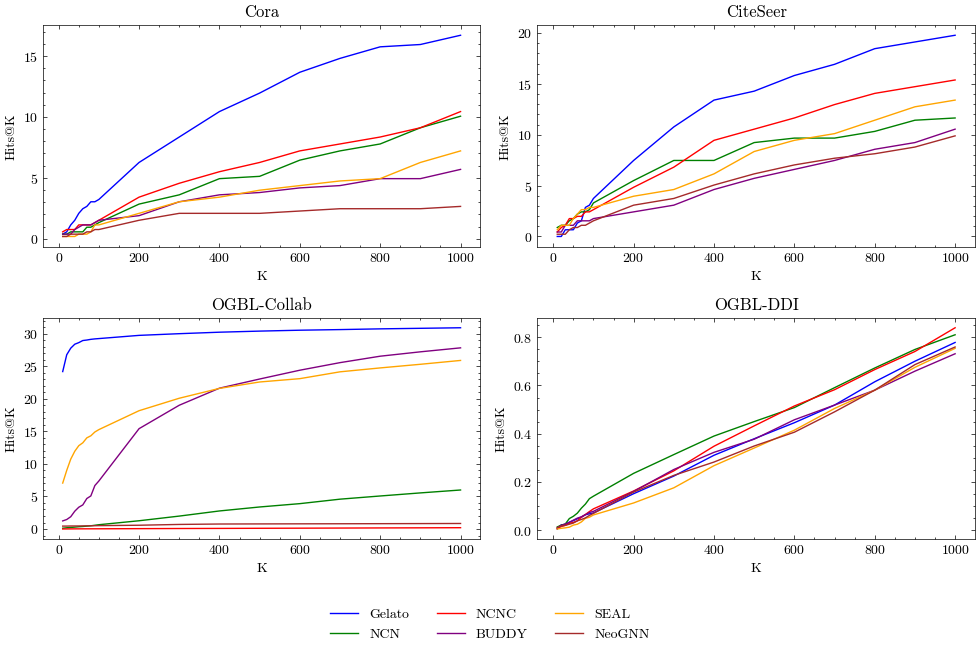

In [29]:
import matplotlib.pyplot as plt
import numpy as np

import seaborn as sns
import scienceplots

plt.style.use(['science', 'no-latex'])


gelato_cora_values = []
ncn_cora_values = []
ncnc_cora_values = []
buddy_cora_values = []
seal_cora_values = []
neognn_cora_values = []

gelato_citeseer_values = []
ncn_citeseer_values = []
ncnc_citeseer_values = []
buddy_citeseer_values = []
seal_citeseer_values = []
neognn_citeseer_values = []

gelato_collab_values = []
ncn_collab_values = []
ncnc_collab_values = []
buddy_collab_values = []
seal_collab_values = []
neognn_collab_values = []

gelato_ddi_values = []
ncn_ddi_values = []
ncnc_ddi_values = []
buddy_ddi_values = []
seal_ddi_values = []
neognn_ddi_values = []


for k in [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]:
    print(k)
    gelato_cora_values.append(hits_at_k(gelato_cora[0]['test_true'], gelato_cora[0]['test_pred'], k))
    ncn_cora_values.append(hits_at_k(ncn_cora[0]['test_true'], ncn_cora[0]['test_pred'], k))
    ncnc_cora_values.append(hits_at_k(ncnc_cora[0]['test_true'], ncnc_cora[0]['test_pred'], k))
    buddy_cora_values.append(hits_at_k(buddy_cora[0]['test_true'], buddy_cora[0]['test_pred'], k))
    seal_cora_values.append(hits_at_k(seal_cora['test_true'], seal_cora['test_pred'], k))
    neognn_cora_values.append(hits_at_k(neognn_cora[0]['test_true'], neognn_cora[0]['test_pred'], k))
    
    
    gelato_citeseer_values.append(hits_at_k(gelato_citeseer[0]['test_true'], gelato_citeseer[0]['test_pred'], k))
    ncn_citeseer_values.append(hits_at_k(ncn_citeseer[0]['test_true'], ncn_citeseer[0]['test_pred'], k))
    ncnc_citeseer_values.append(hits_at_k(ncnc_citeseer[0]['test_true'], ncnc_citeseer[0]['test_pred'], k))
    buddy_citeseer_values.append(hits_at_k(buddy_citeseer[0]['test_true'], buddy_citeseer[0]['test_pred'], k))
    seal_citeseer_values.append(hits_at_k(seal_citeseer['test_true'], seal_citeseer['test_pred'], k))
    neognn_citeseer_values.append(hits_at_k(neognn_citeseer[0]['test_true'], neognn_citeseer[0]['test_pred'], k))
    
    
    gelato_collab_values.append(hits_at_k(gelato_collab[0]['test_true'], gelato_collab[0]['test_pred'], k))
    ncn_collab_values.append(hits_at_k(ncn_collab[0]['test_true'], ncn_collab[0]['test_pred'], k))
    ncnc_collab_values.append(hits_at_k(ncnc_collab[0]['test_true'], ncnc_collab[0]['test_pred'], k))
    buddy_collab_values.append(hits_at_k(buddy_collab[0]['test_true'], buddy_collab[0]['test_pred'], k))
    seal_collab_values.append(hits_at_k(seal_collab['test_true'], seal_collab['test_pred'], k))
    neognn_collab_values.append(hits_at_k(neognn_collab['test_true'], neognn_collab['test_pred'], k))
    
    gelato_ddi_values.append(hits_at_k(gelato_ddi[0]['test_true'], gelato_ddi[0]['test_pred'], k))
    ncn_ddi_values.append(hits_at_k(ncn_ddi[0]['test_true'], ncn_ddi[0]['test_pred'], k))
    ncnc_ddi_values.append(hits_at_k(ncnc_ddi[0]['test_true'], ncnc_ddi[0]['test_pred'], k))
    buddy_ddi_values.append(hits_at_k(buddy_ddi[0]['test_true'], buddy_ddi[0]['test_pred'], k))
    seal_ddi_values.append(hits_at_k(seal_ddi['test_true'], seal_ddi['test_pred'], k))
    neognn_ddi_values.append(hits_at_k(neognn_ddi['test_true'], neognn_ddi['test_pred'], k))


x = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]

# Create a Matplotlib figure and axis
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10, 6))

# Plot the 6 line plots with different colors and labels
ax[0][0].plot(x, np.array(gelato_cora_values) * 100, label='Gelato', color='blue')
ax[0][0].plot(x, np.array(ncn_cora_values) * 100, label='NCN', color='green')
ax[0][0].plot(x, np.array(ncnc_cora_values) * 100, label='NCNC', color='red')
ax[0][0].plot(x, np.array(buddy_cora_values) * 100, label='BUDDY', color='purple')
ax[0][0].plot(x, np.array(seal_cora_values) * 100, label='SEAL', color='orange')
ax[0][0].plot(x, np.array(neognn_cora_values) * 100, label='NeoGNN', color='brown')
ax[0][0].set_title('Cora')

ax[0][1].plot(x, np.array(gelato_citeseer_values) * 100, label='Gelato', color='blue')
ax[0][1].plot(x, np.array(ncn_citeseer_values) * 100, label='NCN', color='green')
ax[0][1].plot(x, np.array(ncnc_citeseer_values) * 100, label='NCNC', color='red')
ax[0][1].plot(x, np.array(buddy_citeseer_values) * 100, label='BUDDY', color='purple')
ax[0][1].plot(x, np.array(seal_citeseer_values) * 100, label='SEAL', color='orange')
ax[0][1].plot(x, np.array(neognn_citeseer_values) * 100, label='NeoGNN', color='brown')
ax[0][1].set_title('CiteSeer')

ax[1][0].plot(np.array(x), np.array(gelato_collab_values) * 100, label='Gelato', color='blue')
ax[1][0].plot(np.array(x), np.array(ncn_collab_values) * 100, label='NCN', color='green')
ax[1][0].plot(np.array(x), np.array(ncnc_collab_values) * 100, label='NCNC', color='red')
ax[1][0].plot(np.array(x), np.array(buddy_collab_values) * 100, label='BUDDY', color='purple')
ax[1][0].plot(np.array(x), np.array(seal_collab_values) * 100, label='SEAL', color='orange')
ax[1][0].plot(np.array(x), np.array(neognn_collab_values) * 100, label='NeoGNN', color='brown')
ax[1][0].set_title('OGBL-Collab')

ax[1][1].plot(x, np.array(gelato_ddi_values) * 100, label='Gelato', color='blue')
ax[1][1].plot(x, np.array(ncn_ddi_values) * 100, label='NCN', color='green')
ax[1][1].plot(x, np.array(ncnc_ddi_values) * 100, label='NCNC', color='red')
ax[1][1].plot(x, np.array(buddy_ddi_values) * 100, label='BUDDY', color='purple')
ax[1][1].plot(x, np.array(seal_ddi_values) * 100, label='SEAL', color='orange')
ax[1][1].plot(x, np.array(neognn_ddi_values) * 100, label='NeoGNN', color='brown')
ax[1][1].set_title('OGBL-DDI')


# Add a legend
# fig.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), shadow=True, ncol=3)
handles, labels = ax[0][0].get_legend_handles_labels()
fig.legend(handles, labels, bbox_to_anchor=(0.5, -0.01), shadow=True, ncol=3, loc='upper center')


# Set axis labels and title
ax[0][0].set_xlabel('K')
ax[0][1].set_xlabel('K')
ax[1][0].set_xlabel('K')
ax[1][1].set_xlabel('K')

ax[0][0].set_ylabel('Hits@K')
ax[0][1].set_ylabel('Hits@K')
ax[1][0].set_ylabel('Hits@K')
ax[1][1].set_ylabel('Hits@K')
# ax.set_ylabel('')
# fig.suptitle('Hits@K')

# set y axis log scale
# ax[0][0].set_yscale('log')
# ax[0][1].set_yscale('log')
# ax[1][0].set_yscale('log')
# ax[1][1].set_yscale('log')

fig.tight_layout()

# Show the plot
plt.show()

fig.savefig("hits@k_four_plots.pdf", bbox_inches='tight')


## Precision@K Plot

10
20
30
40
50
60
70
80
90
100
200
300
400
500
600
700
800
900
1000


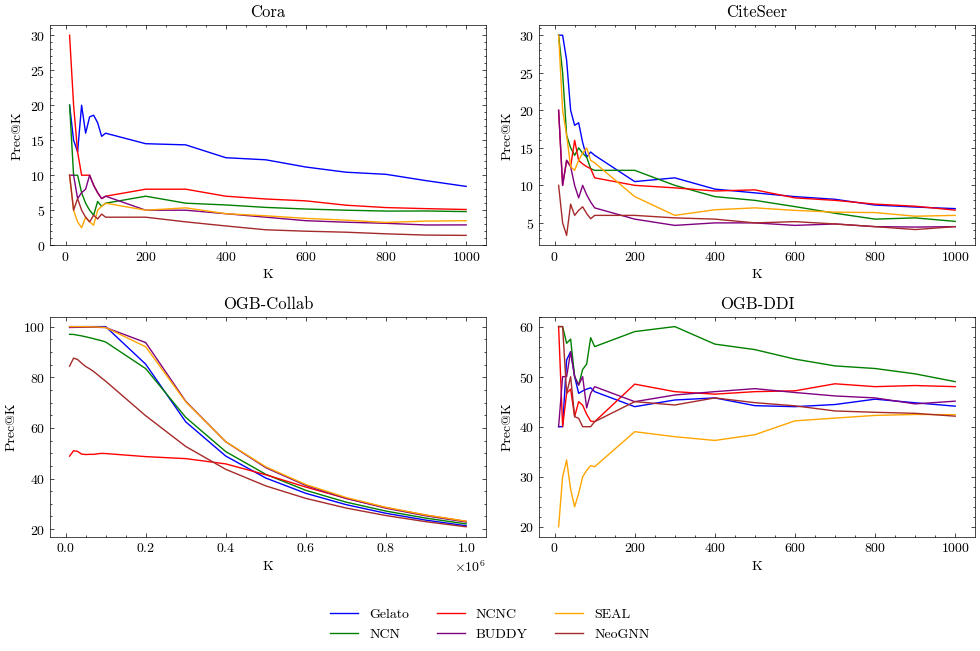

In [133]:
import matplotlib.pyplot as plt
import numpy as np

import seaborn as sns
import scienceplots

plt.style.use(['science', 'no-latex'])


gelato_cora_values = []
ncn_cora_values = []
ncnc_cora_values = []
buddy_cora_values = []
seal_cora_values = []
neognn_cora_values = []

gelato_citeseer_values = []
ncn_citeseer_values = []
ncnc_citeseer_values = []
buddy_citeseer_values = []
seal_citeseer_values = []
neognn_citeseer_values = []

gelato_collab_values = []
ncn_collab_values = []
ncnc_collab_values = []
buddy_collab_values = []
seal_collab_values = []
neognn_collab_values = []

gelato_ddi_values = []
ncn_ddi_values = []
ncnc_ddi_values = []
buddy_ddi_values = []
seal_ddi_values = []
neognn_ddi_values = []


for k in [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]:
    print(k)
    # gelato_cora_values.append(hits_at_k(gelato_cora[0]['test_true'], gelato_cora[0]['test_pred'], k))
    # ncn_cora_values.append(hits_at_k(ncn_cora[0]['test_true'], ncn_cora[0]['test_pred'], k))
    # ncnc_cora_values.append(hits_at_k(ncnc_cora[0]['test_true'], ncnc_cora[0]['test_pred'], k))
    # buddy_cora_values.append(hits_at_k(buddy_cora[0]['test_true'], buddy_cora[0]['test_pred'], k))
    # seal_cora_values.append(hits_at_k(seal_cora['test_true'], seal_cora['test_pred'], k))
    # neognn_cora_values.append(hits_at_k(neognn_cora[0]['test_true'], neognn_cora[0]['test_pred'], k))
    
    
    # gelato_citeseer_values.append(hits_at_k(gelato_citeseer[0]['test_true'], gelato_citeseer[0]['test_pred'], k))
    # ncn_citeseer_values.append(hits_at_k(ncn_citeseer[0]['test_true'], ncn_citeseer[0]['test_pred'], k))
    # ncnc_citeseer_values.append(hits_at_k(ncnc_citeseer[0]['test_true'], ncnc_citeseer[0]['test_pred'], k))
    # buddy_citeseer_values.append(hits_at_k(buddy_citeseer[0]['test_true'], buddy_citeseer[0]['test_pred'], k))
    # seal_citeseer_values.append(hits_at_k(seal_citeseer['test_true'], seal_citeseer['test_pred'], k))
    # neognn_citeseer_values.append(hits_at_k(neognn_citeseer[0]['test_true'], neognn_citeseer[0]['test_pred'], k))
    
    
    # gelato_collab_values.append(hits_at_k(gelato_collab[0]['test_true'], gelato_collab[0]['test_pred'], k))
    # ncn_collab_values.append(hits_at_k(ncn_collab[0]['test_true'], ncn_collab[0]['test_pred'], k))
    # ncnc_collab_values.append(hits_at_k(ncnc_collab[0]['test_true'], ncnc_collab[0]['test_pred'], k))
    # buddy_collab_values.append(hits_at_k(buddy_collab[0]['test_true'], buddy_collab[0]['test_pred'], k))
    # seal_collab_values.append(hits_at_k(seal_collab['test_true'], seal_collab['test_pred'], k))
    # neognn_collab_values.append(hits_at_k(neognn_collab['test_true'], neognn_collab['test_pred'], k))
    
    # gelato_ddi_values.append(hits_at_k(gelato_ddi[0]['test_true'], gelato_ddi[0]['test_pred'], k))
    # ncn_ddi_values.append(hits_at_k(ncn_ddi[0]['test_true'], ncn_ddi[0]['test_pred'], k))
    # ncnc_ddi_values.append(hits_at_k(ncnc_ddi[0]['test_true'], ncnc_ddi[0]['test_pred'], k))
    # buddy_ddi_values.append(hits_at_k(buddy_ddi[0]['test_true'], buddy_ddi[0]['test_pred'], k))
    # seal_ddi_values.append(hits_at_k(seal_ddi['test_true'], seal_ddi['test_pred'], k))
    # neognn_ddi_values.append(hits_at_k(neognn_ddi['test_true'], neognn_ddi['test_pred'], k))

    
    gelato_cora_values.append(precision_at_k(gelato_cora[0]['test_true'], gelato_cora[0]['test_pred'], k))
    ncn_cora_values.append(precision_at_k(ncn_cora[0]['test_true'], ncn_cora[0]['test_pred'], k))
    ncnc_cora_values.append(precision_at_k(ncnc_cora[0]['test_true'], ncnc_cora[0]['test_pred'], k))
    buddy_cora_values.append(precision_at_k(buddy_cora[0]['test_true'], buddy_cora[0]['test_pred'], k))
    seal_cora_values.append(precision_at_k(seal_cora['test_true'], seal_cora['test_pred'], k))
    neognn_cora_values.append(precision_at_k(neognn_cora[0]['test_true'], neognn_cora[0]['test_pred'], k))
    
    
    gelato_citeseer_values.append(precision_at_k(gelato_citeseer[0]['test_true'], gelato_citeseer[0]['test_pred'], k))
    ncn_citeseer_values.append(precision_at_k(ncn_citeseer[0]['test_true'], ncn_citeseer[0]['test_pred'], k))
    ncnc_citeseer_values.append(precision_at_k(ncnc_citeseer[0]['test_true'], ncnc_citeseer[0]['test_pred'], k))
    buddy_citeseer_values.append(precision_at_k(buddy_citeseer[0]['test_true'], buddy_citeseer[0]['test_pred'], k))
    seal_citeseer_values.append(precision_at_k(seal_citeseer['test_true'], seal_citeseer['test_pred'], k))
    neognn_citeseer_values.append(precision_at_k(neognn_citeseer[0]['test_true'], neognn_citeseer[0]['test_pred'], k))
    
    
    gelato_collab_values.append(precision_at_k(gelato_collab[0]['test_true'], gelato_collab[0]['test_pred'], 1000 * k))
    ncn_collab_values.append(precision_at_k(ncn_collab[0]['test_true'], ncn_collab[0]['test_pred'], 1000 * k))
    ncnc_collab_values.append(precision_at_k(ncnc_collab[0]['test_true'], ncnc_collab[0]['test_pred'], 1000 * k))
    buddy_collab_values.append(precision_at_k(buddy_collab[0]['test_true'], buddy_collab[0]['test_pred'], 1000 * k))
    seal_collab_values.append(precision_at_k(seal_collab['test_true'], seal_collab['test_pred'], 1000 * k))
    neognn_collab_values.append(precision_at_k(neognn_collab['test_true'], neognn_collab['test_pred'], 1000 * k))
    
    gelato_ddi_values.append(precision_at_k(gelato_ddi[0]['test_true'], gelato_ddi[0]['test_pred'], k))
    ncn_ddi_values.append(precision_at_k(ncn_ddi[0]['test_true'], ncn_ddi[0]['test_pred'], k))
    ncnc_ddi_values.append(precision_at_k(ncnc_ddi[0]['test_true'], ncnc_ddi[0]['test_pred'], k))
    buddy_ddi_values.append(precision_at_k(buddy_ddi[0]['test_true'], buddy_ddi[0]['test_pred'], k))
    seal_ddi_values.append(precision_at_k(seal_ddi['test_true'], seal_ddi['test_pred'], k))
    neognn_ddi_values.append(precision_at_k(neognn_ddi['test_true'], neognn_ddi['test_pred'], k))


x = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]

# Create a Matplotlib figure and axis
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10, 6))

# Plot the 6 line plots with different colors and labels
ax[0][0].plot(x, np.array(gelato_cora_values) * 100, label='Gelato', color='blue')
ax[0][0].plot(x, np.array(ncn_cora_values) * 100, label='NCN', color='green')
ax[0][0].plot(x, np.array(ncnc_cora_values) * 100, label='NCNC', color='red')
ax[0][0].plot(x, np.array(buddy_cora_values) * 100, label='BUDDY', color='purple')
ax[0][0].plot(x, np.array(seal_cora_values) * 100, label='SEAL', color='orange')
ax[0][0].plot(x, np.array(neognn_cora_values) * 100, label='NeoGNN', color='brown')
ax[0][0].set_title('Cora')

ax[0][1].plot(x, np.array(gelato_citeseer_values) * 100, label='Gelato', color='blue')
ax[0][1].plot(x, np.array(ncn_citeseer_values) * 100, label='NCN', color='green')
ax[0][1].plot(x, np.array(ncnc_citeseer_values) * 100, label='NCNC', color='red')
ax[0][1].plot(x, np.array(buddy_citeseer_values) * 100, label='BUDDY', color='purple')
ax[0][1].plot(x, np.array(seal_citeseer_values) * 100, label='SEAL', color='orange')
ax[0][1].plot(x, np.array(neognn_citeseer_values) * 100, label='NeoGNN', color='brown')
ax[0][1].set_title('CiteSeer')

ax[1][0].plot(1000 * np.array(x), np.array(gelato_collab_values) * 100, label='Gelato', color='blue')
ax[1][0].plot(1000 * np.array(x), np.array(ncn_collab_values) * 100, label='NCN', color='green')
ax[1][0].plot(1000 * np.array(x), np.array(ncnc_collab_values) * 100, label='NCNC', color='red')
ax[1][0].plot(1000 * np.array(x), np.array(buddy_collab_values) * 100, label='BUDDY', color='purple')
ax[1][0].plot(1000 * np.array(x), np.array(seal_collab_values) * 100, label='SEAL', color='orange')
ax[1][0].plot(1000 * np.array(x), np.array(neognn_collab_values) * 100, label='NeoGNN', color='brown')
ax[1][0].set_title('OGB-Collab')

ax[1][1].plot(x, np.array(gelato_ddi_values) * 100, label='Gelato', color='blue')
ax[1][1].plot(x, np.array(ncn_ddi_values) * 100, label='NCN', color='green')
ax[1][1].plot(x, np.array(ncnc_ddi_values) * 100, label='NCNC', color='red')
ax[1][1].plot(x, np.array(buddy_ddi_values) * 100, label='BUDDY', color='purple')
ax[1][1].plot(x, np.array(seal_ddi_values) * 100, label='SEAL', color='orange')
ax[1][1].plot(x, np.array(neognn_ddi_values) * 100, label='NeoGNN', color='brown')
ax[1][1].set_title('OGB-DDI')


# Add a legend
# fig.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), shadow=True, ncol=3)
handles, labels = ax[0][0].get_legend_handles_labels()
fig.legend(handles, labels, bbox_to_anchor=(0.5, -0.01), shadow=True, ncol=3, loc='upper center')


# Set axis labels and title
ax[0][0].set_xlabel('K')
ax[0][1].set_xlabel('K')
ax[1][0].set_xlabel('K')
ax[1][1].set_xlabel('K')

ax[0][0].set_ylabel('Prec@K')
ax[0][1].set_ylabel('Prec@K')
ax[1][0].set_ylabel('Prec@K')
ax[1][1].set_ylabel('Prec@K')
# ax.set_ylabel('')
# fig.suptitle('Hits@K')

# set y axis log scale
# ax[0][0].set_yscale('log')
# ax[0][1].set_yscale('log')
# ax[1][0].set_yscale('log')
# ax[1][1].set_yscale('log')

fig.tight_layout()

# Show the plot
plt.show()

fig.savefig("prec@k_four_plots.pdf", bbox_inches='tight')


In [132]:
precision_at_k(gelato_collab[0]['test_true'], gelato_collab[0]['test_pred'], 800_000)

0.26262625

## GNN Results

In [88]:
gelato_cora_train = [torch.load(f'/home/jrm28/gelato/original_gelato/results/train_Cora_{i}_100_full_idk.pth', map_location=torch.device('cpu')) for i in range(1, 4)]

gelato_cora_train_results = []
for results in gelato_cora_train:
    gelato_cora_train_results.append(compute_all_metrics(torch.tensor(results['train_true']), torch.tensor(results['train_pred'])))
    
mean, std = calculate_mean_and_stddev(gelato_cora_train_results)
format_keys(mean, std)


gelato_gnn_cora_train = [torch.load(f'/home/jrm28/gelato/original_gelato/results/gnn_results/train_Cora_{i}_100_full.pth', map_location=torch.device('cpu')) for i in range(0, 3)]

gelato_gnn_cora_train_results = []
for results in gelato_cora_train:
    gelato_gnn_cora_train_results.append(compute_all_metrics(torch.tensor(results['train_true']), torch.tensor(results['train_pred'])))
    
mean, std = calculate_mean_and_stddev(gelato_gnn_cora_train_results)
format_keys(mean, std)

{'prec@100%': '18.85 ± 0.0',
 'prec@10': '10.0 ± 0.0',
 'prec@100': '44.0 ± 0.0',
 'prec@1000': '33.6 ± 0.0',
 'hits@10': '0.02 ± 0.0',
 'hits@100': '1.56 ± 0.0',
 'hits@1000': '10.2 ± 0.0',
 'mrr': '0.0789 ± 0.0',
 'auc': '74.53 ± 0.0',
 'ap': '8.69 ± 0.0'}

In [89]:
gelato_citeseer_train = [torch.load(f'/home/jrm28/gelato/original_gelato/results/train_CiteSeer_{i}_150_full_idk.pth', map_location=torch.device('cpu')) for i in range(1, 4)]

gelato_citeseer_train_results = []
for results in gelato_citeseer_train:
    gelato_citeseer_train_results.append(compute_all_metrics(torch.tensor(results['train_true']), torch.tensor(results['train_pred'])))
    
mean, std = calculate_mean_and_stddev(gelato_citeseer_train_results)
format_keys(mean, std)


gelato_gnn_citeseer_train = [torch.load(f'/home/jrm28/gelato/original_gelato/results/gnn_results/train_CiteSeer_{i}_150_full.pth', map_location=torch.device('cpu')) for i in range(0, 3)]

gelato_gnn_citeseer_train_results = []
for results in gelato_citeseer_train:
    gelato_gnn_citeseer_train_results.append(compute_all_metrics(torch.tensor(results['train_true']), torch.tensor(results['train_pred'])))
    
mean, std = calculate_mean_and_stddev(gelato_gnn_citeseer_train_results)
format_keys(mean, std)

{'prec@100%': '12.03 ± 0.0',
 'prec@10': '50.0 ± 0.0',
 'prec@100': '51.0 ± 0.0',
 'prec@1000': '27.3 ± 0.0',
 'hits@10': '0.22 ± 0.0',
 'hits@100': '1.76 ± 0.0',
 'hits@1000': '7.35 ± 0.0',
 'mrr': '0.1063 ± 0.0',
 'auc': '55.14 ± 0.0',
 'ap': '4.58 ± 0.0'}

In [81]:
gelato_ddi_train = [torch.load(f'/home/jrm28/gelato/original_gelato/results/train_ogbl-ddi_{i}_150_full_idk.pth', map_location=torch.device('cpu')) for i in range(1, 4)]

gelato_ddi_train_results = []
for results in gelato_ddi_train:
    gelato_ddi_train_results.append(compute_all_metrics(torch.tensor(results['train_true']), torch.tensor(results['train_pred'])))
    
mean, std = calculate_mean_and_stddev(gelato_ddi_train_results)
format_keys(mean, std)


gelato_gnn_ddi_train = [torch.load(f'/home/jrm28/gelato/original_gelato/results/gnn_results/train_ogbl-ddi_{i}_250_full.pth', map_location=torch.device('cpu')) for i in range(0, 3)]

gelato_gnn_ddi_train_results = []
for results in gelato_ddi_train:
    gelato_gnn_ddi_train_results.append(compute_all_metrics(torch.tensor(results['train_true']), torch.tensor(results['train_pred'])))
    
mean, std = calculate_mean_and_stddev(gelato_gnn_ddi_train_results)
format_keys(mean, std)

{'prec@100%': '42.82 ± 0.0',
 'prec@10': '0.0 ± 0.0',
 'prec@100': '0.0 ± 0.0',
 'prec@1000': '0.0 ± 0.0',
 'hits@10': '0.0 ± 0.0',
 'hits@100': '0.0 ± 0.0',
 'hits@1000': '0.0 ± 0.0',
 'mrr': '0.0006 ± 0.0',
 'auc': '70.73 ± 0.0',
 'ap': '31.62 ± 0.0'}

In [128]:
gelato_cora_values = []
gelato_citeseer_values = []
gelato_ddi_values = []

gelato_gnn_cora_values = []
gelato_gnn_citeseer_values = []
gelato_gnn_ddi_values = []

gelato_cora_values_train = []
gelato_citeseer_values_train = []
gelato_ddi_values_train = []

gelato_gnn_cora_values_train = []
gelato_gnn_citeseer_values_train = []
gelato_gnn_ddi_values_train = []

for k in [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]:
    print(k)
    
    gelato_cora_values.append(precision_at_k(gelato_cora[0]['test_true'], gelato_cora[0]['test_pred'], k))
    gelato_citeseer_values.append(precision_at_k(gelato_citeseer[0]['test_true'], gelato_citeseer[0]['test_pred'], k))
    # gelato_ddi_values.append(precision_at_k(gelato_ddi[0]['test_true'], gelato_ddi[0]['test_pred'], k))

    
    gelato_gnn_cora_values.append(precision_at_k(gelato_gnn_cora[0]['test_true'], gelato_gnn_cora[0]['test_pred'], k))
    gelato_gnn_citeseer_values.append(precision_at_k(gelato_gnn_citeseer[0]['test_true'], gelato_gnn_citeseer[0]['test_pred'], k))
    # gelato_gnn_ddi_values.append(precision_at_k(gelato_gnn_ddi[0]['test_true'], gelato_gnn_ddi[0]['test_pred'], k))
    
    gelato_cora_values_train.append(precision_at_k(torch.tensor(gelato_cora_train[0]['train_true']), torch.tensor(gelato_cora_train[0]['train_pred']), k))
    gelato_citeseer_values_train.append(precision_at_k(torch.tensor(gelato_citeseer_train[0]['train_true']), torch.tensor(gelato_citeseer_train[0]['train_pred']), k))
    # gelato_ddi_values_train.append(precision_at_k(torch.tensor(gelato_ddi_train[0]['train_true']), torch.tensor(gelato_ddi_train[0]['train_pred']), k))
    
    
    gelato_gnn_cora_values_train.append(precision_at_k(torch.tensor(gelato_gnn_cora_train[0]['train_true']), torch.tensor(gelato_gnn_cora_train[0]['train_pred']), k))
    gelato_gnn_citeseer_values_train.append(precision_at_k(torch.tensor(gelato_gnn_citeseer_train[0]['train_true']), torch.tensor(gelato_gnn_citeseer_train[0]['train_pred']), k))
    # gelato_gnn_ddi_values_train.append(hits_at_k(torch.tensor(gelato_gnn_ddi_train[0]['train_true']), torch.tensor(gelato_gnn_ddi_train[0]['train_pred']), k))

10
20
30
40
50
60
70
80
90
100
200
300
400
500
600
700
800
900
1000


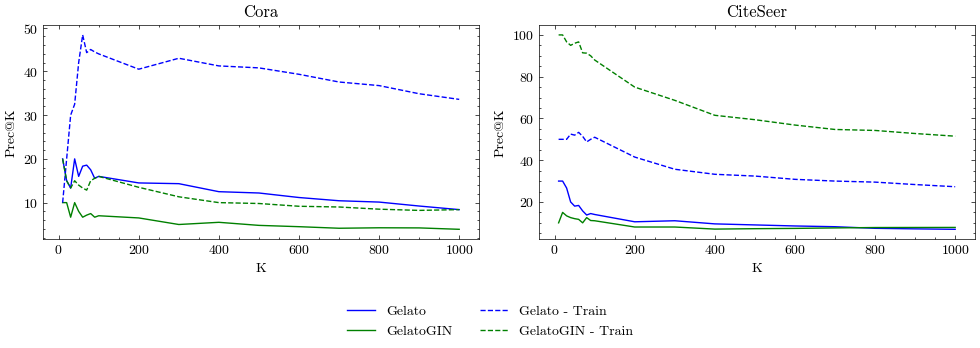

In [134]:
import matplotlib.pyplot as plt
import numpy as np

import seaborn as sns
import scienceplots

plt.style.use(['science', 'no-latex'])


x = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]

# Create a Matplotlib figure and axis
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 3))

# Plot the 6 line plots with different colors and labels
ax[0].plot(x, np.array(gelato_cora_values) * 100, label='Gelato', color='blue')
ax[0].plot(x, np.array(gelato_gnn_cora_values) * 100, label='GelatoGIN', color='green')
ax[0].plot(x, np.array(gelato_cora_values_train) * 100, label='Gelato - Train', color='blue', linestyle='--')
ax[0].plot(x, np.array(gelato_gnn_cora_values_train) * 100, label='GelatoGIN - Train', color='green', linestyle='--')
ax[0].set_title('Cora')

ax[1].plot(x, np.array(gelato_citeseer_values) * 100, label='Gelato', color='blue')
ax[1].plot(x, np.array(gelato_gnn_citeseer_values) * 100, label='GelatoGIN', color='green')
ax[1].plot(x, np.array(gelato_citeseer_values_train) * 100, label='Gelato - Train', color='blue', linestyle='--')
ax[1].plot(x, np.array(gelato_gnn_citeseer_values_train) * 100, label='GelatoGIN - Train', color='green', linestyle='--')
ax[1].set_title('CiteSeer')

# ax[2].plot(x, np.array(gelato_ddi_values) * 100, label='Gelato', color='blue')
# ax[2].plot(x, np.array(gelato_gnn_ddi_values) * 100, label='GelatoGIN', color='green')
# ax[2].plot(x, np.array(gelato_ddi_values_train) * 100, label='Gelato - Train', color='blue', linestyle='--')
# ax[2].plot(x, np.array(gelato_gnn_ddi_values_train) * 100, label='GelatoGIN - Train', color='green', linestyle='--')
# ax[2].set_title('DDI')


# Add a legend
# fig.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), shadow=True, ncol=3)
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, bbox_to_anchor=(0.5, -0.01), shadow=True, ncol=2, loc='upper center')


# Set axis labels and title
ax[0].set_xlabel('K')
ax[1].set_xlabel('K')
# ax[2].set_xlabel('K')

ax[0].set_ylabel('Prec@K')
ax[1].set_ylabel('Prec@K')
# ax[2].set_ylabel('Prec@K')


# fig.suptitle('Prec@K')


fig.tight_layout()

# Show the plot
plt.show()

fig.savefig("prec@k_gnn.pdf", bbox_inches='tight')


## Learning $\alpha$ and $\beta$

10
20
30
40
50
60
70
80
90
100
200
300
400
500
600
700
800
900
1000


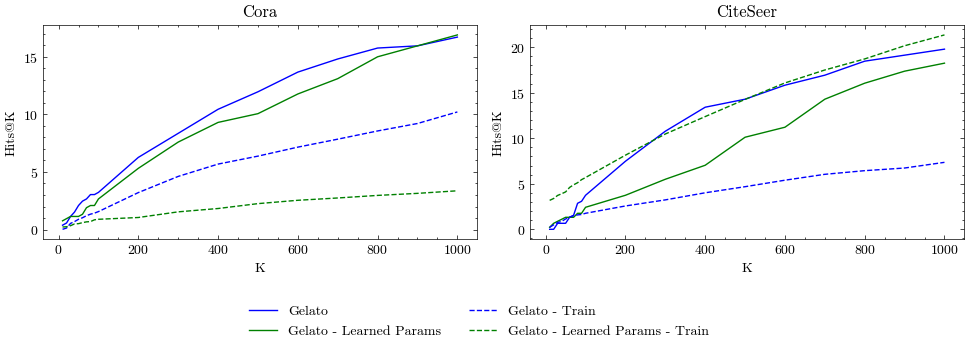

In [93]:
import matplotlib.pyplot as plt
import numpy as np

import seaborn as sns
import scienceplots

plt.style.use(['science', 'no-latex'])


x = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]

# Create a Matplotlib figure and axis
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 3))

gelato_cora_learned_params = torch.load("/home/jrm28/gelato/original_gelato/results/learn_alpha_beta/Cora_0_100_full.pth", map_location=torch.device('cpu'))
gelato_citeseer_learned_params = torch.load("/home/jrm28/gelato/original_gelato/results/learn_alpha_beta/CiteSeer_0_150_full.pth", map_location=torch.device('cpu'))
gelato_cora_learned_params_train = torch.load("/home/jrm28/gelato/original_gelato/results/learn_alpha_beta/train_Cora_0_100_full.pth", map_location=torch.device('cpu'))
gelato_citeseer_learned_params_train = torch.load("/home/jrm28/gelato/original_gelato/results/learn_alpha_beta/train_CiteSeer_0_150_full.pth", map_location=torch.device('cpu'))




gelato_cora_values = []
gelato_cora_learned_params_values = []
gelato_citeseer_values = []
gelato_citeseer_learned_params_values = []

gelato_cora_values_train = []
gelato_cora_learned_params_values_train = []
gelato_citeseer_values_train = []
gelato_citeseer_learned_params_values_train = []


for k in [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]:
    print(k)
    
    gelato_cora_values.append(hits_at_k(gelato_cora[0]['test_true'], gelato_cora[0]['test_pred'], k))
    gelato_citeseer_values.append(hits_at_k(gelato_citeseer[0]['test_true'], gelato_citeseer[0]['test_pred'], k))
    gelato_cora_values_train.append(hits_at_k(torch.tensor(gelato_cora_train[0]['train_true']), torch.tensor(gelato_cora_train[0]['train_pred']), k))
    gelato_citeseer_values_train.append(hits_at_k(torch.tensor(gelato_citeseer_train[0]['train_true']), torch.tensor(gelato_citeseer_train[0]['train_pred']), k))
    
    gelato_cora_learned_params_values.append(hits_at_k(gelato_cora_learned_params['test_true'], gelato_cora_learned_params['test_pred'], k))
    gelato_citeseer_learned_params_values.append(hits_at_k(gelato_citeseer_learned_params['test_true'], gelato_citeseer_learned_params['test_pred'], k))
    gelato_cora_learned_params_values_train.append(hits_at_k(torch.tensor(gelato_cora_learned_params_train['train_true']), torch.tensor(gelato_cora_learned_params_train['train_pred']), k))
    gelato_citeseer_learned_params_values_train.append(hits_at_k(torch.tensor(gelato_citeseer_learned_params_train['train_true']), torch.tensor(gelato_citeseer_learned_params_train['train_pred']), k))
    


# Plot the 6 line plots with different colors and labels
ax[0].plot(x, np.array(gelato_cora_values) * 100, label='Gelato', color='blue')
ax[0].plot(x, np.array(gelato_cora_learned_params_values) * 100, label='Gelato - Learned Params', color='green')
ax[0].plot(x, np.array(gelato_cora_values_train) * 100, label='Gelato - Train', color='blue', linestyle='--')
ax[0].plot(x, np.array(gelato_cora_learned_params_values_train) * 100, label='Gelato - Learned Params - Train', color='green', linestyle='--')
ax[0].set_title('Cora')

ax[1].plot(x, np.array(gelato_citeseer_values) * 100, label='Gelato', color='blue')
ax[1].plot(x, np.array(gelato_citeseer_learned_params_values) * 100, label='Gelato - Learned Parameters', color='green')
ax[1].plot(x, np.array(gelato_citeseer_values_train) * 100, label='Gelato - Train', color='blue', linestyle='--')
ax[1].plot(x, np.array(gelato_citeseer_learned_params_values_train) * 100, label='Gelato - Learned Params - Train', color='green', linestyle='--')
ax[1].set_title('CiteSeer')

# ax[2].plot(x, np.array(gelato_ddi_values) * 100, label='Gelato', color='blue')
# ax[2].plot(x, np.array(gelato_gnn_ddi_values) * 100, label='GelatoGIN', color='green')
# ax[2].plot(x, np.array(gelato_ddi_values_train) * 100, label='Gelato - Train', color='blue', linestyle='--')
# ax[2].plot(x, np.array(gelato_gnn_ddi_values_train) * 100, label='GelatoGIN - Train', color='green', linestyle='--')
# ax[2].set_title('DDI')


# Add a legend
# fig.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), shadow=True, ncol=3)
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, bbox_to_anchor=(0.5, -0.01), shadow=True, ncol=2, loc='upper center')


# Set axis labels and title
ax[0].set_xlabel('K')
ax[1].set_xlabel('K')
# ax[2].set_xlabel('K')

ax[0].set_ylabel('Hits@K')
ax[1].set_ylabel('Hits@K')
# ax[2].set_ylabel('Prec@K')


# fig.suptitle('Prec@K')


fig.tight_layout()

# Show the plot
plt.show()

fig.savefig("learned_params_hits.pdf", bbox_inches='tight')


## Sensitivity Analysis

In [177]:
import pandas as pd

cora = pd.read_csv('CoraSweep.csv')
citeseer = pd.read_csv('CiteSeerSweep.csv')
ddi = pd.read_csv('DDISweep.csv')

In [199]:
cora = cora.sort_values('val_ap', ascending=False)
mask = cora[['alpha', 'beta']].duplicated(keep='first').values
cora_non_duplicates_best_result = cora[~mask]


citeseer = citeseer.sort_values('val_ap', ascending=False)
mask = citeseer[['alpha', 'beta']].duplicated(keep='first').values
citeseer_non_duplicates_best_result = citeseer[~mask]

In [189]:
cora_non_duplicates_best_result.pivot(index='alpha', columns='beta', values='val_ap')

# sort pivot table columns descending
cora_non_duplicates_best_result.pivot(index='alpha', columns='beta', values='val_ap').sort_index(axis=1, ascending=False)

# sort pivot table rows descending
cora_non_duplicates_best_result.pivot(index='alpha', columns='beta', values='val_ap').sort_index(axis=0, ascending=False).transpose()

alpha,0.75,0.50,0.25,0.00
beta,,,,
0.25,0.015108,0.016387,0.013609,0.009401
0.50,0.015194,0.016504,0.014894,0.011275
0.75,0.015455,0.016942,0.017023,0.012018
1.00,0.014736,0.016277,0.016596,0.013475


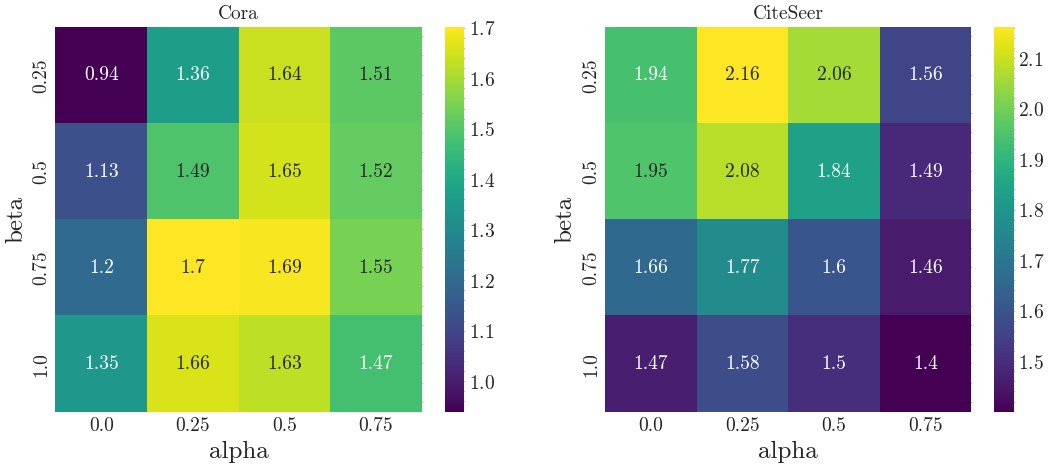

In [224]:
import seaborn as sns
import matplotlib

plt.style.use(['science', 'no-latex'])


import matplotlib.pyplot as plt

SMALL_SIZE = 14
MEDIUM_SIZE = 18
BIGGER_SIZE = 120

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title
# sns.set(font_scale=1)


plt.rcParams['text.usetex'] = False 

cmap = sns.color_palette("viridis", as_cmap=True)

fig, ax = plt.subplots(1,2, figsize=(13, 5))


sns.heatmap(cora_non_duplicates_best_result.pivot(index='alpha', columns='beta', values='val_ap').sort_index(axis=0, ascending=True).transpose() * 100, annot=True, fmt='.3g', cmap=cmap, ax=ax[0]);

sns.heatmap(citeseer_non_duplicates_best_result.pivot(index='alpha', columns='beta', values='val_ap').sort_index(axis=0, ascending=True).transpose() * 100, annot=True, fmt='.3g', cmap=cmap, ax=ax[1]);


ax[0].set(title='Cora')
ax[1].set(title='CiteSeer')

fig.show()

fig.savefig("sensitivity_analysis.pdf", bbox_inches='tight')


## Losses

In [11]:
# Precision at k loss
pk_citeseer = [torch.load(f'/home/jrm28/gelato/original_gelato/results/losses/CiteSeer_pk_{i}_100_full.pth', map_location=torch.device('cpu')) for i in range(0, 3)]
pk_cora = [torch.load(f'/home/jrm28/gelato/original_gelato/results/losses/Cora_pk_{i}_100_full.pth', map_location=torch.device('cpu')) for i in range(0, 3)]
pk_ddi = [torch.load(f'/home/jrm28/gelato/original_gelato/results/losses/ogbl-ddi_pk_{i}_250_full.pth', map_location=torch.device('cpu')) for i in range(0, 3)]

pk_cora_results = []
pk_citeseer_results = []
pk_ddi_results = []
for results_citeseer, results_cora, results_ddi in zip(pk_citeseer, pk_cora, pk_ddi):
    pk_citeseer_results.append(compute_all_metrics(results_citeseer['test_true'], results_citeseer['test_pred']))
    pk_cora_results.append(compute_all_metrics(results_cora['test_true'], results_cora['test_pred']))
    pk_ddi_results.append(compute_all_metrics(results_ddi['test_true'], results_ddi['test_pred']))
    
mean, std = calculate_mean_and_stddev(pk_citeseer_results)
pk_citeseer_results = format_keys(mean, std)
mean, std = calculate_mean_and_stddev(pk_cora_results)
pk_cora_results = format_keys(mean, std)
mean, std = calculate_mean_and_stddev(pk_ddi_results)
pk_ddi_results = format_keys(mean, std)

# Hinge
ph_citeseer = [torch.load(f'/home/jrm28/gelato/original_gelato/results/losses/CiteSeer_ph_{i}_100_full.pth', map_location=torch.device('cpu')) for i in range(0, 3)]
ph_cora = [torch.load(f'/home/jrm28/gelato/original_gelato/results/losses/Cora_ph_{i}_100_full.pth', map_location=torch.device('cpu')) for i in range(0, 3)]
ph_ddi = [torch.load(f'/home/jrm28/gelato/original_gelato/results/losses/ogbl-ddi_ph_{i}_250_full.pth', map_location=torch.device('cpu')) for i in range(0, 3)]

ph_cora_results = []
ph_citeseer_results = []
ph_ddi_results = []
for results_citeseer, results_cora, results_ddi in zip(ph_citeseer, ph_cora, ph_ddi):
    ph_citeseer_results.append(compute_all_metrics(results_citeseer['test_true'], results_citeseer['test_pred']))
    ph_cora_results.append(compute_all_metrics(results_cora['test_true'], results_cora['test_pred']))
    ph_ddi_results.append(compute_all_metrics(results_ddi['test_true'], results_ddi['test_pred']))
    
mean, std = calculate_mean_and_stddev(ph_citeseer_results)
ph_citeseer_results = format_keys(mean, std)
mean, std = calculate_mean_and_stddev(ph_cora_results)
ph_cora_results = format_keys(mean, std)
mean, std = calculate_mean_and_stddev(ph_ddi_results)
ph_ddi_results = format_keys(mean, std)


# Exponential
pe_citeseer = [torch.load(f'/home/jrm28/gelato/original_gelato/results/losses/CiteSeer_pe_{i}_100_full.pth', map_location=torch.device('cpu')) for i in range(0, 3)]
pe_cora = [torch.load(f'/home/jrm28/gelato/original_gelato/results/losses/Cora_pe_{i}_100_full.pth', map_location=torch.device('cpu')) for i in range(0, 3)]
pe_ddi = [torch.load(f'/home/jrm28/gelato/original_gelato/results/losses/ogbl-ddi_pe_{i}_250_full.pth', map_location=torch.device('cpu')) for i in range(0, 3)]

pe_cora_results = []
pe_citeseer_results = []
pe_ddi_results = []
for results_citeseer, results_cora, results_ddi in zip(pe_citeseer, pe_cora, pe_ddi):
    pe_citeseer_results.append(compute_all_metrics(results_citeseer['test_true'], results_citeseer['test_pred']))
    pe_cora_results.append(compute_all_metrics(results_cora['test_true'], results_cora['test_pred']))
    pe_ddi_results.append(compute_all_metrics(results_ddi['test_true'], results_ddi['test_pred']))
    
mean, std = calculate_mean_and_stddev(pe_citeseer_results)
pe_citeseer_results = format_keys(mean, std)
mean, std = calculate_mean_and_stddev(pe_cora_results)
pe_cora_results = format_keys(mean, std)
mean, std = calculate_mean_and_stddev(pe_ddi_results)
pe_ddi_results = format_keys(mean, std)

pl_citeseer = [torch.load(f'/home/jrm28/gelato/original_gelato/results/losses/CiteSeer_pl_{i}_100_full.pth', map_location=torch.device('cpu')) for i in range(0, 3)]
pl_cora = [torch.load(f'/home/jrm28/gelato/original_gelato/results/losses/Cora_pl_{i}_100_full.pth', map_location=torch.device('cpu')) for i in range(0, 3)]
pl_ddi = [torch.load(f'/home/jrm28/gelato/original_gelato/results/losses/ogbl-ddi_pl_{i}_250_full.pth', map_location=torch.device('cpu')) for i in range(0, 3)]

pl_cora_results = []
pl_citeseer_results = []
pl_ddi_results = []
for results_citeseer, results_cora, results_ddi in zip(pl_citeseer, pl_cora, pl_ddi):
    pe_citeseer_results.append(compute_all_metrics(results_citeseer['test_true'], results_citeseer['test_pred']))
    pe_cora_results.append(compute_all_metrics(results_cora['test_true'], results_cora['test_pred']))
    pe_ddi_results.append(compute_all_metrics(results_ddi['test_true'], results_ddi['test_pred']))

mean, std = calculate_mean_and_stddev(pl_citeseer_results)
pl_citeseer_results = format_keys(mean, std)
mean, std = calculate_mean_and_stddev(pl_cora_results)
pl_cora_results = format_keys(mean, std)
mean, std = calculate_mean_and_stddev(pl_ddi_results)
pl_ddi_results = format_keys(mean, std)

In [26]:
pl_citeseer = [torch.load(f'/home/jrm28/gelato/original_gelato/results/losses/CiteSeer_pl_{i}_100_full.pth', map_location=torch.device('cpu')) for i in range(0, 3)]
pl_cora = [torch.load(f'/home/jrm28/gelato/original_gelato/results/losses/Cora_pl_{i}_100_full.pth', map_location=torch.device('cpu')) for i in range(0, 3)]
pl_ddi = [torch.load(f'/home/jrm28/gelato/original_gelato/results/losses/ogbl-ddi_pl_{i}_250_full.pth', map_location=torch.device('cpu')) for i in range(0, 3)]

pl_cora_results = []
pl_citeseer_results = []
pl_ddi_results = []
for results_citeseer, results_cora, results_ddi in zip(pl_citeseer, pl_cora, pl_ddi):
    pl_citeseer_results.append(compute_all_metrics(results_citeseer['test_true'], results_citeseer['test_pred']))
    pl_cora_results.append(compute_all_metrics(results_cora['test_true'], results_cora['test_pred']))
    pl_ddi_results.append(compute_all_metrics(results_ddi['test_true'], results_ddi['test_pred']))

mean, std = calculate_mean_and_stddev(pl_citeseer_results)
pl_citeseer_results = format_keys(mean, std)
mean, std = calculate_mean_and_stddev(pl_cora_results)
pl_cora_results = format_keys(mean, std)
mean, std = calculate_mean_and_stddev(pl_ddi_results)
pl_ddi_results = format_keys(mean, std)

In [38]:
cols = ['Cora', 'CiteSeer', 'DDI']

metric = 'hits@1000'

rows = {'Gelato-PK' : [pk_cora_results[metric], pk_citeseer_results[metric]],
        'Gelato-PH' : [ph_cora_results[metric], ph_citeseer_results[metric]],
        'Gelato-PE' : [pe_cora_results[metric], pe_citeseer_results[metric]],
        'Gelato-PL' : [pl_cora_results[metric], pl_citeseer_results[metric]],
        'Gelato' : [gelato_cora_results[metric], gelato_citeseer_results[metric]]}

print(results2latex(cols, rows))

\begin{table*}[t]
\centering
\caption{Results}
\label{tab:results}
\begin{tabular}{lccc}
\toprule
Cora & CiteSeer & DDI \\
\midrule
Gelato-PK & 16.32 ± 0.19 & 19.19 ± 0.99 \\
Gelato-PH & 18.09 ± 0.48 & 16.56 ± 0.13 \\
Gelato-PE & 16.82 ± 0.48 & 15.9 ± 0.34 \\
Gelato-PL & 18.03 ± 0.38 & 17.14 ± 0.66 \\
Gelato & 16.7 ± 0.0 & 19.89 ± 0.24 \\
\bottomrule
\end{tabular}
\end{table*}

